# Perennial Snow Persistence — Beas Kund Cirque (2017–2024)

Multi-sensor (Sentinel-2 + Landsat 8/9) mapping of **perennial snow/ice** — surface that survives
the late-summer ablation minimum across multiple years — over the Beas Kund cirque, Himachal Pradesh.

**Method lineage.** Multi-year snow persistence follows the USGS approach (Selkowitz & Forster 2016):
classify each clear look as snow / not-snow by NDSI over a late-summer window, then require
persistence across years. Extensions here (novel): per-tile-acquisition multi-sensor fusion,
a ablation-minimum timing weight, asymmetric evidence (bare is easier to prove than perennial),
and an explicit no-data / water / undecided split so every pixel's status has a *reason*.

**Reflectance screens** follow the MODIS/VIIRS snow ATBD (positive-reflectance + low-VIS screens
before NDSI). **Ablation-minimum window** (late Aug – mid Sept) is grounded in the same-basin
MODIS/ERA5 study (Beas basin; Aug SCA minimum) and cross-checked against this project's own
pooled snow-fraction-vs-day-of-year curve.

> **Reproducibility note.** Stage 3 fetches and classifies imagery once and caches it to disk.
> After the first run it is offline — re-running the notebook reuses the cache and skips the network.

---
### Key decisions (see DECISIONS.md for full rationale)
- **Mask uses all 8 years (2017–2024).** Thin early years (2017–18) are *load-bearing*: they push
  ~9.7k pixels over the MIN_YEARS bar. Dropping them *loses* decided pixels, so they stay.
- **Bare is a yearly aggregate, never a per-epoch veto.** A single stray not-snow look (thin cloud,
  poorly-timed look, mixed edge pixel) must not disqualify a genuinely perennial pixel.
- **Change study (Stage 7) uses a *different*, smaller year set** than the mask — the fixed
  observable intersection — for reasons explained in that section.

## Configuration

AOI, grid, thresholds, sensor registry, class codes. All tunable parameters live here.

In [1]:
import os
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr, rioxarray
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from pyproj import Transformer
import pystac_client, planetary_computer
import matplotlib.pyplot as plt

# ---- AOI & grid ----
BBOX  = [77.03373, 32.31549, 77.14879, 32.41271]   # Beas Kund cirque
UTM   = "EPSG:32643"                                # UTM 43N (local zone for this AOI)
RES   = 30.0                                        # 30 m: Landsat-native; Sentinel downsampled to it
YEARS = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]   # WHY: all 8 kept — early years are load-bearing (rescue pixels over MIN_YEARS)
WIN   = ("08-01", "10-01")                          # search window (brackets the ablation minimum)

# ---- classification / persistence thresholds ----
MAX_TILE_CLOUD   = 0.60    # reject an acquisition if >60% of its own footprint is obstructed
NDSI_SNOW        = 0.40    # NDSI > 0.40 = snow (MODIS/Sentinel-Hub standard)
MIN_OBS_PER_YEAR = 2       # a year needs >=2 clear land looks to be considered at all
YEAR_SNOW_FRAC   = 0.80    # WHY: >=80% of a year's clear looks are snow -> snow-that-year (tolerates a noise minority)
# --- per-year verdict look-floors (PRAGMATIC, uncalibrated) ---
# WHY asymmetric: the 0.80 snow rule assumes room to absorb a stray bare (noise) look, so it needs
# enough looks to be meaningful; declaring BARE (snow absent) is unambiguous and needs fewer looks.
# NOTE: these floors are engineering heuristics, NOT calibrated to a per-look error rate — no such rate
# exists in the literature (papers report scene-level accuracy, not per-observation miss probability),
# and we have no in-situ Beas Kund data to calibrate against. See DECISIONS.md.
# gate SNOW on the count of actual SNOW looks, not total looks: a unanimous 2-snow-look pixel is strong
# evidence and must NOT be punished for thin coverage; a single snow look could be noise. This scales
# the requirement with the evidence (frac 1.0 needs only 2; frac 0.80 naturally needs more snow looks).
MIN_SNOW_LOOKS   = 2       # >=2 clear looks must actually see snow to call a year snow-dominant
BARE_MIN_LOOKS   = 2       # bare needs only a small floor (snow's absence is unambiguous)
MAX_BARE_YEARS   = 2       # WHY: perennial tolerates bare in <=2 decided years (2/8 = 25%; localised-study value, revisit for wide-area)
MIN_YEARS        = 3       # WHY: >=3 decided years to make any PERENNIAL/NOT call; fewer = UNDECIDED (honest "too thin")

# ---- ablation-minimum-weighted confidence (ablation minimum ~ late Aug – mid Sept for this monsoon-basin AOI) ----
# WHY these dates: same-basin Beas MODIS/ERA5 study (Aug SCA minimum) + this project's own snow-frac-vs-DOY curve.
# A snow look is trusted most near the ablation minimum; weight decays for too-early (incomplete melt) or too-late (fresh snow) last-looks.
ABL_MIN_LO   = "08-25"
ABL_MIN_HI   = "09-15"
CONF_FLOOR = 0.20          # floor weight at the window edges
PERENNIAL_W = 0.75         # decade: ablation-minimum-weighted perennial fraction needed to call PERENNIAL

# ---- class codes ----
NOT_PERENNIAL, UNDECIDED, PERENNIAL, CANDIDATE, NO_DATA, WATER = 0, 1, 2, 3, 4, 5

CACHE = Path("cache_perennial"); OUT = Path("out_perennial")
(CACHE / "epochs").mkdir(parents=True, exist_ok=True)
(CACHE / "year").mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

# ---- multi-sensor registry (S2 + L8 + L9) ----
# WHY fusion: Landsat's clear-sky days are independent of Sentinel's, filling ablation-minimum-window cloud gaps.
# Per sensor: STAC collection, green/SWIR assets, reflectance scale/offset, cloud-mask kind.
SENSORS = {
    "S2": dict(collection="sentinel-2-l2a",
               green="B03", swir="B11", mask="SCL", mask_kind="scl",
               scale=1/10000.0, offset=-1000/10000.0),        # (DN-1000)/10000
    "L8": dict(collection="landsat-c2-l2", platform="landsat-8",
               green="green", swir="swir16", mask="qa_pixel", mask_kind="qa_pixel",
               scale=0.0000275, offset=-0.2),                  # DN*0.0000275 - 0.2
    "L9": dict(collection="landsat-c2-l2", platform="landsat-9",
               green="green", swir="swir16", mask="qa_pixel", mask_kind="qa_pixel",
               scale=0.0000275, offset=-0.2),
}
# Landsat QA_PIXEL bit flags (Collection-2 CFMask): fill0 dilated1 cirrus2 cloud3 shadow4 snow5 water7
QA_CLOUD_BITS = [1, 2, 3]   # dilated/cirrus/cloud -> overridable by NDSI snow
QA_SHADOW_BIT = 4
QA_FILL_BIT   = 0
QA_WATER_BIT  = 7

## Setup: reference grid, band loaders, mask decoders

Builds the common 30 m grid every sensor is resampled onto, and the per-sensor cloud/water decoders (SCL classes for Sentinel, QA_PIXEL bits for Landsat). Everything converges to the same snow/not-snow/masked/water logic after this.

In [2]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace)

# build the fixed reference grid (AOI bbox -> UTM -> RES-metre cells)
_t = Transformer.from_crs("EPSG:4326", UTM, always_xy=True)
_cx, _cy = zip(*[_t.transform(x, y) for x in (BBOX[0], BBOX[2]) for y in (BBOX[1], BBOX[3])])
minx, maxx, miny, maxy = min(_cx), max(_cx), min(_cy), max(_cy)
W = int(np.ceil((maxx - minx) / RES)); H = int(np.ceil((maxy - miny) / RES))
xs = minx + RES * (np.arange(W) + 0.5); ys = maxy - RES * (np.arange(H) + 0.5)
REF = xr.DataArray(np.zeros((H, W), "float32"), coords={"y": ys, "x": xs}, dims=("y", "x"))
REF.rio.write_crs(UTM, inplace=True)
REF.rio.write_transform(from_origin(minx, maxy, RES, RES), inplace=True)

def _reproject(a, categorical):
    a = a.squeeze().rio.write_nodata(np.nan)
    r = Resampling.nearest if categorical else Resampling.average   # average = honest downsample of S2 to 30 m
    return a.astype("float32").rio.reproject_match(REF, resampling=r, nodata=np.nan)

def load_band(item, asset, categorical=False):
    a = (rioxarray.open_rasterio(item.assets[asset].href, masked=True)
         .rio.clip_box(BBOX[0], BBOX[1], BBOX[2], BBOX[3], crs="EPSG:4326"))
    return _reproject(a, categorical)

def _cloud_and_snow_masks(item, sensor, ndsi_snow):
    # Returns (hard, cloud, off, water) on the REF grid.
    #   hard  = always drop (fill / shadow / off-tile)
    #   cloud = drop UNLESS the pixel is NDSI-snow (Landsat/SCL both over-flag bright snow as cloud)
    #   water = a KNOWN surface (not no-data) -> excluded from the snow/bare question, own class
    s = SENSORS[sensor]
    if s["mask_kind"] == "scl":                        # Sentinel-2: integer classes
        scl  = load_band(item, s["mask"], categorical=True).values
        off  = ~np.isfinite(scl)
        scli = np.where(off, 0, scl).astype("int16")
        water = np.isin(scli, [6])
        hard  = np.isin(scli, [0, 1, 3]) | off         # nodata/saturated/shadow
        cloud = np.isin(scli, [8, 9, 10])              # cloud med/high/cirrus
        return hard, cloud, off, water
    else:                                              # Landsat: bit-packed QA_PIXEL
        qa  = load_band(item, s["mask"], categorical=True).values
        off = ~np.isfinite(qa)
        q   = np.where(off, 0, qa).astype("uint16")
        bit = lambda b: (q >> b) & 1
        water = (bit(QA_WATER_BIT) == 1)
        hard  = (bit(QA_FILL_BIT) == 1) | (bit(QA_SHADOW_BIT) == 1) | off
        cloud = np.zeros_like(off)
        for b in QA_CLOUD_BITS: cloud |= (bit(b) == 1)
        return hard, cloud, off, water

def save_like(arr, path, dtype):
    da = xr.DataArray(arr.astype(dtype), coords={"y": REF.y, "x": REF.x}, dims=("y", "x"))
    da.rio.write_crs(REF.rio.crs, inplace=True)
    da.rio.write_transform(REF.rio.transform(), inplace=True)
    da.rio.to_raster(path)

print(f"reference grid {H}x{W} @ {RES} m  {UTM}  |  sensors: {list(SENSORS)}")

reference grid 367x368 @ 30.0 m  EPSG:32643  |  sensors: ['S2', 'L8', 'L9']


## Stage 1 — Acquisition search

Search every sensor's late-summer window for each year. **Each acquisition (tile × date × sensor) is its own unit** — this is what lets two Sentinel tiles and independent Landsat passes all feed the same pixel without one starving the other.

In [3]:
# STAGE 1 — search all sensors; every (year, date, sensor, tile) acquisition is an independent unit
records, items_by_key = [], {}
for y in YEARS:
    for sen, sconf in SENSORS.items():
        q = dict(collections=[sconf["collection"]], bbox=BBOX, datetime=f"{y}-{WIN[0]}/{y}-{WIN[1]}")
        if "platform" in sconf:                        # split Landsat-8 vs Landsat-9
            q["query"] = {"platform": {"eq": sconf["platform"]}}
        for it in catalog.search(**q).items():
            d = pd.to_datetime(it.datetime).date()
            tile = it.properties.get("s2:mgrs_tile") or \
                   f'{it.properties.get("landsat:wrs_path","")}-{it.properties.get("landsat:wrs_row","")}'
            key = (d.year, d, sen, tile)
            if key in items_by_key: continue
            items_by_key[key] = it
            records.append({"year": d.year, "date": d, "sensor": sen, "tile": tile})
acq = pd.DataFrame(records).sort_values(["date", "sensor", "tile"]).reset_index(drop=True)
print(f"{len(acq)} acquisitions across {len(YEARS)} seasons")
print(acq.groupby(["year", "sensor"]).size().unstack(fill_value=0).to_string())

358 acquisitions across 8 seasons
sensor  L8  L9  S2
year              
2017     8   0  18
2018     8   0  36
2019     8   0  37
2020     8   0  38
2021     8   0  38
2022     6   5  38
2023     8   8  38
2024     8   8  32


## Stage 2 — Per-acquisition cloud gating

Measure cloud/obstruction over **each acquisition's own footprint** (not the whole AOI) and keep those under the threshold. Per-footprint gating is why a cloudy Sentinel tile doesn't drag down a clear Landsat pass on the same date. Result is cached to `catalogue.csv`.

In [4]:
# STAGE 2 — per-acquisition obstruction fraction over its own footprint; cache the verdict table
def acq_cloud(item, sensor):
    hard, cloud, off, water = _cloud_and_snow_masks(item, sensor, NDSI_SNOW)
    seen = ~off
    if not seen.any(): return 1.0, 0.0
    cloudy = cloud | (hard & ~off)
    return float(cloudy[seen].mean()), float(seen.mean())

csv_path = CACHE / "catalogue.csv"
done = {}
if csv_path.exists():
    prev = pd.read_csv(csv_path, parse_dates=["date"]); prev["date"] = prev["date"].dt.date
    if "sensor" in prev.columns:                        # guard: ignore stale-schema cache
        done = {(r.year, r.date, r.sensor, str(r.tile)): (r.aoi_cloud, r.coverage) for r in prev.itertuples()}

rows = []
for r in acq.itertuples():
    key = (r.year, r.date, r.sensor, str(r.tile))
    if key in done:
        cf, cov = done[key]
    else:
        try:    cf, cov = acq_cloud(items_by_key[(r.year, r.date, r.sensor, r.tile)], r.sensor)
        except Exception as e: cf, cov = 1.0, 0.0; print(f"{r.date} {r.sensor} {r.tile}: {e}")
    rows.append({"year": r.year, "date": r.date, "sensor": r.sensor, "tile": r.tile,
                 "aoi_cloud": round(cf, 3), "coverage": round(cov, 3), "pass": cf <= MAX_TILE_CLOUD})
    pd.DataFrame(rows).to_csv(csv_path, index=False)
catalogue = pd.DataFrame(rows)
print("passing acquisitions per sensor per year:")
print(catalogue[catalogue["pass"]].groupby(["year","sensor"]).size().unstack(fill_value=0).to_string())

passing acquisitions per sensor per year:
sensor  L8  L9  S2
year              
2017     3   0   6
2018     0   0   8
2019     2   0   9
2020     2   0  17
2021     1   0  14
2022     2   0  12
2023     0   0  15
2024     0   3   7


## Stage 3 — Classification & caching  *(run once, then offline)*

Classify each passing acquisition to snow / not-snow / masked / water and cache the array per `(date, sensor, tile)`.

**Reflectance screens (MODIS/VIIRS ATBD) applied before NDSI** — this fixed a real bug where unmasked
nodata (DN=0 → −0.1 reflectance) and Sen2Cor over-unity values blew NDSI far outside [−1, 1]:
- clip reflectance to [0, 1]  → kills nodata + over-unity artifacts, keeps bright snow
- require both bands > 0 and green > 0.10 (low-VIS screen) → rejects dark-surface false snow

**NDSI overrides cloud on snow**: SCL and Landsat CFMask both over-flag bright snow as cloud, so a pixel
that reads NDSI-snow is kept even if the cloud mask flagged it.

> Once the `.npy` cache exists this stage is fully offline; the loop skips already-cached acquisitions.

In [5]:
# STAGE 3 — classify each passing acquisition (sensor-aware); cache per (date, sensor, tile)
def classify(item, sensor):
    s = SENSORS[sensor]
    g = np.clip(load_band(item, s["green"]).values * s["scale"] + s["offset"], 0.0, 1.0)
    w = np.clip(load_band(item, s["swir"]).values  * s["scale"] + s["offset"], 0.0, 1.0)
    valid = np.isfinite(g) & np.isfinite(w) & (g > 0.0) & (w > 0.0) & (g > 0.10)   # ATBD screens
    ndsi  = np.where(valid, (g - w) / (g + w), np.nan)
    snow  = (ndsi > NDSI_SNOW) & valid
    hard, cloud, off, water = _cloud_and_snow_masks(item, sensor, NDSI_SNOW)
    masked = hard | (cloud & ~snow) | ~valid            # NDSI rescues snow the cloud mask over-flagged
    st = np.where(masked, -1, np.where(snow, 1, 0)).astype("int8")   # -1 masked, 0 not-snow, 1 snow
    st = np.where(water & ~snow & ~masked, 2, st).astype("int8")     # 2 = water (known surface)
    return st

for r in catalogue[catalogue["pass"]].itertuples():
    yd = CACHE / "epochs" / str(r.year); yd.mkdir(parents=True, exist_ok=True)
    fp = yd / f"{r.date}_{r.sensor}_{r.tile}.npy"
    if fp.exists(): continue                            # offline resume: skip cached
    try:
        np.save(fp, classify(items_by_key[(r.year, r.date, r.sensor, r.tile)], r.sensor))
        print(f"cached {r.date} {r.sensor} {r.tile}")
    except Exception as e:
        print(f"{r.date} {r.sensor} {r.tile}: FAILED {e}")

## Stage 4 — Per-year verdict

Reduce each year's stack of clear looks to one verdict per pixel. **Bare is decided on the yearly
aggregate, not per epoch** — this was the single most important correction in the whole pipeline.

- `snow_frac` = fraction of the year's clear *land* looks (snow or bare; water excluded) that were snow.
- **snow-that-year** if `snow_frac ≥ 0.80` **and** the year has `≥ SNOW_MIN_LOOKS` looks — the 80% rule
  tolerates a ~20% noise minority (thin cloud, poorly-timed looks, mixed edges), which is only meaningful with
  enough looks to leave room for that tolerance.
- **bare-that-year** if not snow-dominant **and** `≥ BARE_MIN_LOOKS` looks — bare (snow's absence) is
  unambiguous, so it needs a much smaller look floor. This is the asymmetry: snow needs evidence, bare is easy.
- **abstain** otherwise (thin or too few looks to trust the fraction). Abstaining years are **not** counted
  as decided, so they can neither inflate the decided-year count nor drag confidence.
- **confidence** = the best (closest to the ablation minimum) snow look's tent weight — recency handled *within* the year here.

> There is deliberately **no** 0.20–0.80 "dead zone": anything below the snow bar is bare (given enough
> looks) or an abstain (too thin). An earlier version carried a symmetric `≤0.20 = bare` floor left over
> from when snow and bare were treated symmetrically; it silently let mid-fraction years count as decided
> while adding zero confidence, biasing pixels toward not-perennial. Removed.

> The look-floors (`SNOW_MIN_LOOKS`, `BARE_MIN_LOOKS`) are **pragmatic, uncalibrated** heuristics — see
> DECISIONS.md. No per-look snow-miss error rate exists in the literature to calibrate them, and there is
> no in-situ Beas Kund data; they are honest engineering choices, not tuned parameters.

In [6]:
# STAGE 4 — per-year verdict: yearly-aggregate snow fraction + ablation-minimum-weighted confidence
import datetime as _dt
def _doy(s): return _dt.date(2001, int(s[:2]), int(s[3:])).timetuple().tm_yday
_LO, _HI = _doy(ABL_MIN_LO), _doy(ABL_MIN_HI)
_WSTART, _WEND = _doy(WIN[0]), _doy(WIN[1])

def _tent(doy):                                         # ablation-minimum timing weight for a last-look date
    if _LO <= doy <= _HI: return 1.0                    # on the ablation-minimum plateau
    if doy < _LO:  f = (doy - _WSTART) / max(_LO - _WSTART, 1)   # too early: incomplete melt
    else:          f = (_WEND - doy) / max(_WEND - _HI, 1)       # too late: fresh snow risk
    return float(CONF_FLOOR + (1 - CONF_FLOOR) * max(0.0, min(1.0, f)))

year_pw, year_bare, year_dec, year_water, year_nvalid = {}, {}, {}, {}, {}
print("year  n_acquisitions")
for y in YEARS:
    yd = CACHE / "epochs" / str(y)
    files = sorted(yd.glob("*.npy")) if yd.exists() else []
    print(f"{y}   {len(files):>2}")
    if not files:
        for dct in (year_pw, year_bare, year_dec, year_water, year_nvalid):
            dct[y] = np.zeros((H, W), "float32" if dct is year_pw else
                              ("int16" if dct is year_nvalid else bool))
        continue

    S, doys = [], []
    for f in files:
        S.append(np.load(f))
        doys.append(_dt.date(*map(int, f.stem.split("_")[0].split("-"))).timetuple().tm_yday)
    S = np.stack(S); doys = np.array(doys)              # states -1/0/1/2

    is_snow, is_bare, is_water = (S == 1), (S == 0), (S == 2)
    valid  = is_snow | is_bare                          # land looks only (water excluded)
    nsnow, nvalid = is_snow.sum(0), valid.sum(0)
    snow_frac = np.where(nvalid > 0, nsnow / np.maximum(nvalid, 1), 0.0)

    # asymmetric per-year verdict (no 0.20-0.80 "dead zone" — that was legacy symmetric-threshold code):
    #   SNOW  = snow-dominant (>=0.80) AND enough looks to trust the noise-tolerant fraction
    #   BARE  = not snow-dominant AND enough looks that the fraction is real (small floor; bare is easy)
    #   else -> abstain (thin/ambiguous): NOT counted as decided, so it can't inflate ndec or drag conf
    year_is_snow = (snow_frac >= YEAR_SNOW_FRAC) & (nsnow >= MIN_SNOW_LOOKS)
    year_is_bare = ~year_is_snow & (snow_frac < YEAR_SNOW_FRAC) & (nvalid >= BARE_MIN_LOOKS)
    has_valid    = year_is_snow | year_is_bare          # DECIDED = reached a verdict (snow or bare)
    year_is_water = is_water.any(0) & ~has_valid

    tent = np.array([_tent(d) for d in doys], dtype="float32")
    best_w = ((S == 1) * tent[:, None, None]).max(0).astype("float32")   # best ablation-minimum-weighted snow look

    year_pw[y]     = np.where(year_is_snow, best_w, 0.0).astype("float32")
    year_bare[y]   = year_is_bare
    year_dec[y]    = has_valid
    year_water[y]  = year_is_water
    year_nvalid[y] = nvalid.astype("int16")
    save_like(year_pw[y], CACHE / "year" / f"{y}_pw.tif", "float32")

year  n_acquisitions
2017    9
2018    8
2019   11
2020   19
2021   15
2022   14
2023   15
2024   10


## Stage 5 — Multi-year persistence → perennial mask

Combine the per-year verdicts into one class per pixel. Confidence across years is a plain mean of the
(already ablation-minimum-weighted) yearly confidences — recency matters *within* a year, not *between* years.

**Asymmetric evidence** — the core logic:
- **PERENNIAL** is a strong persistence claim → needs `≥ MIN_YEARS` decided years **and** high mean
  confidence **and** bare in `≤ MAX_BARE_YEARS` years.
- **NOT-PERENNIAL** is *easier* to prove → bare in `> MAX_BARE_YEARS` years rules out perennial
  **regardless of total decided years** (no MIN_YEARS needed). Positive bare evidence is decisive.

**Every non-verdict pixel gets a *reason*, not a shrug:**
- **NO_DATA** — the trusted masks (cloud/shadow/water/off-tile) rejected *every* look (`ndec == 0`).
- **WATER** — a known water surface, excluded from the snow question entirely.
- **UNDECIDED** — genuinely observed but too thin (`0 < ndec < MIN_YEARS`) and not bare enough to rule out.
- **CANDIDATE** — an undecided pixel fully ringed by perennial (deferred for optional interpolation).

In [7]:
# STAGE 5 — decade reduction: asymmetric evidence + explicit no-data/water/undecided split
PW   = np.stack([year_pw[y]   for y in YEARS])
BARE = np.stack([year_bare[y] for y in YEARS])
DEC  = np.stack([year_dec[y]  for y in YEARS])
ndec = DEC.sum(0).astype("int16")                       # decided-years count (honesty layer)
water_years = np.stack([year_water[y] for y in YEARS]).sum(0).astype("int16")

with np.errstate(invalid="ignore"):
    conf = np.where(ndec > 0, PW.sum(0) / np.maximum(ndec, 1), 0.0).astype("float32")
bare_years = BARE.sum(0).astype("int16")

cls = np.full((H, W), UNDECIDED, "int8")
cls[ndec == 0] = NO_DATA                                # masks ate every look here (not indecision)
cls[(ndec == 0) & (water_years > 0)] = WATER            # known water surface
enough   = ndec >= MIN_YEARS
too_bare = bare_years > MAX_BARE_YEARS                  # decisive against perennial, no MIN_YEARS needed
cls[enough & (conf >= PERENNIAL_W) & ~too_bare] = PERENNIAL
cls[(enough & ((conf < PERENNIAL_W) | too_bare)) | too_bare] = NOT_PERENNIAL

# CANDIDATE: undecided interior pixel fully ringed by perennial (deferred interpolation target)
per = (cls == PERENNIAL).astype("int8"); pad = np.pad(per, 1)
cnt = sum(pad[1+dy:1+dy+H, 1+dx:1+dx+W] for dy in (-1,0,1) for dx in (-1,0,1) if not (dy==0 and dx==0))
cls[(cls == UNDECIDED) & (cnt == 8)] = CANDIDATE

save_like(cls, OUT / "perennial_class.tif", "int8")
save_like(ndec, OUT / "valid_years.tif", "int16")
save_like(bare_years, OUT / "bare_years.tif", "int16")
save_like(conf, OUT / "perennial_confidence.tif", "float32")
np.save(OUT / "peryear_pw.npy", PW)                     # inputs for the interannual-change section
np.save(OUT / "peryear_bare.npy", BARE)

vals, counts = np.unique(cls, return_counts=True)
names = {0:"not-perennial",1:"undecided",2:"PERENNIAL",3:"candidate",4:"no-data",5:"water"}
print("final class pixel counts:")
for v, c in zip(vals, counts):
    print(f"  {names.get(int(v), v):14s} {c:>7d}  ({c/cls.size:.1%})")
if (cls == PERENNIAL).any():
    print(f"\nmean confidence over PERENNIAL pixels: {conf[cls==PERENNIAL].mean():.2f}")

final class pixel counts:
  not-perennial    70848  (52.5%)
  undecided        36324  (26.9%)
  PERENNIAL         6711  (5.0%)
  no-data          21151  (15.7%)
  water               22  (0.0%)

mean confidence over PERENNIAL pixels: 0.83


## Stage 6 — Visualize the mask

Class map, decided-years count (the honesty layer), and ablation-minimum-weighted confidence. A well-behaved result has PERENNIAL sitting exactly where confidence is high, on the high cirques.

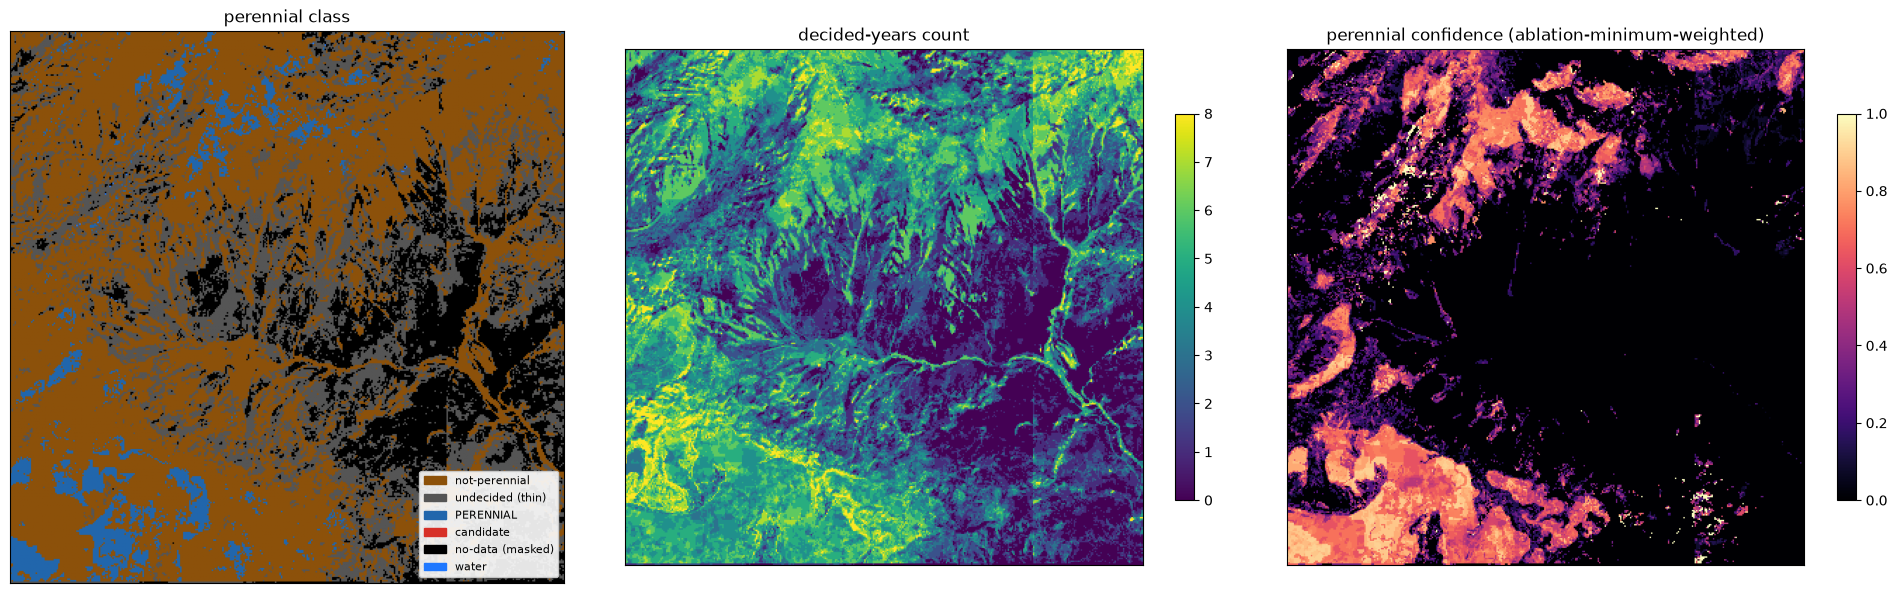

In [8]:
# STAGE 6 — class map + decided-years + confidence
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
colors = ["#8c510a", "#555555", "#2166ac", "#d73027", "#000000", "#1f78ff"]
ccmap = mcolors.ListedColormap(colors)

fig, ax = plt.subplots(1, 3, figsize=(20, 6))
ax[0].imshow(cls, cmap=ccmap, vmin=-0.5, vmax=5.5)
ax[0].set_title("perennial class")
ax[0].legend(handles=[Patch(color=c, label=l) for c, l in zip(colors,
             ["not-perennial","undecided (thin)","PERENNIAL","candidate","no-data (masked)","water"])],
             loc="lower right", fontsize=8, framealpha=0.9)
im1 = ax[1].imshow(ndec, cmap="viridis", vmin=0, vmax=len(YEARS))
ax[1].set_title("decided-years count"); plt.colorbar(im1, ax=ax[1], shrink=0.7)
im2 = ax[2].imshow(conf, cmap="magma", vmin=0, vmax=1)
ax[2].set_title("perennial confidence (ablation-minimum-weighted)"); plt.colorbar(im2, ax=ax[2], shrink=0.7)
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## Interannual change (observation-controlled)

**Not a decadal trend — a short, honestly-scoped 4-year comparison.**

The change question needs the *same pixels* measured every year, otherwise year-to-year sampling drift
(which terrain happened to be cloud-free) masquerades as real change. That means a **fixed intersection**:
pixels with a binary perennial verdict in *every* study year. Measuring change on a fixed pixel set is
what keeps the signal honest — any rise or fall is real change on that ground, not a change in *what we
could see*.

**Why the study years differ from the mask years.** The full 8-year intersection is nearly empty
(~2.2k px) because 2017/18/20/21 are thin. Dropping those to a well-observed set **grows** the comparable
intersection to ~33k px (2019, 2022, 2023, 2024). So the **mask** keeps all 8 years (more evidence, early
years rescue pixels), while the **change study** intersects down to the 4 well-observed years (bigger
comparable set). They pull in opposite directions on purpose — they answer different questions.

**Scope and known limits (stated, not corrected):**
- Observation is uneven — persistent cloud, terrain shadow, and per-sensor gaps mean some parts of the
  AOI are seen far more than others. The fixed intersection (~25% of the AOI) is the subset reliably seen
  in all study years; the trend applies to *that ground*, not the whole basin.
- We do **not** characterise the terrain composition of the observable set, and we make **no**
  aspect-differentiated (north- vs south-slope) melt claim — that is outside this study's scope.
- The verdict unit is **binary** (perennial-that-year yes/no), never a confidence delta — different
  sensors and acquisition timing make confidence *values* non-comparable across years.

fixed observable set: 33488 px (24.8% of AOI)
  2019:  18865 perennial (56.3% of fixed set)
  2022:  13948 perennial (41.7% of fixed set)
  2023:  14049 perennial (42.0% of fixed set)
  2024:  11859 perennial (35.4% of fixed set)
net change 2019->2024: -7006 px (-20.9 pts)


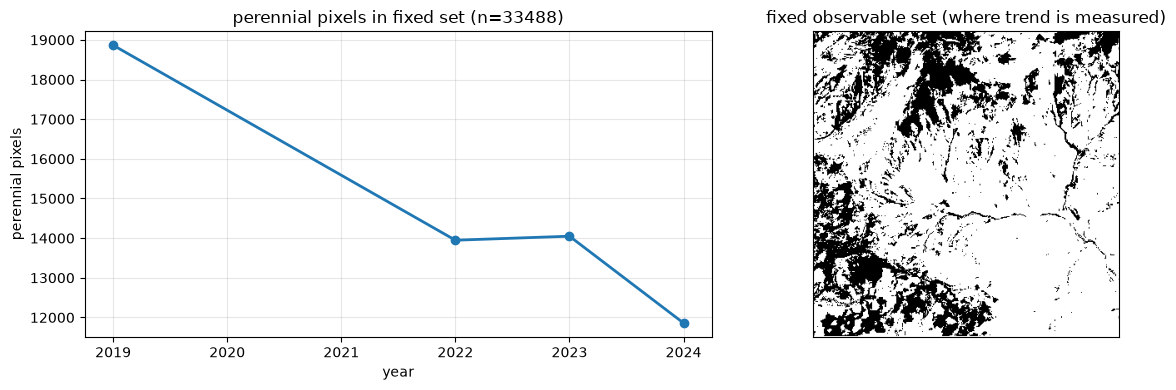

In [9]:
# INTERANNUAL CHANGE — fixed observable intersection, binary perennial count per year
STUDY_YEARS = [2019, 2022, 2023, 2024]                  # WHY: well-observed subset -> largest comparable intersection

DECs = np.stack([year_dec[y]  for y in STUDY_YEARS])    # decided-that-year
PERY = np.stack([(year_pw[y] > 0) for y in STUDY_YEARS])# binary perennial-that-year
fixed = DECs.all(0)                                     # observable in EVERY study year (the fixed set)
n_fixed = int(fixed.sum())
print(f"fixed observable set: {n_fixed} px ({fixed.mean():.1%} of AOI)")

counts = [int((PERY[k] & fixed).sum()) for k in range(len(STUDY_YEARS))]
for y, c in zip(STUDY_YEARS, counts):
    print(f"  {y}: {c:>6d} perennial ({c/n_fixed:.1%} of fixed set)")
print(f"net change {STUDY_YEARS[0]}->{STUDY_YEARS[-1]}: {counts[-1]-counts[0]:+d} px "
      f"({(counts[-1]-counts[0])/n_fixed*100:+.1f} pts)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(STUDY_YEARS, counts, "o-", lw=2)
ax[0].set_title(f"perennial pixels in fixed set (n={n_fixed})")
ax[0].set_xlabel("year"); ax[0].set_ylabel("perennial pixels"); ax[0].grid(alpha=.3)
ax[1].imshow(fixed, cmap="Greys"); ax[1].set_title("fixed observable set (where trend is measured)")
ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout(); plt.show()